In [1]:
import os 
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from utils import * 

# 1D cases analysis

In [2]:
log1d_paths = glob.glob('../logs/exp1d/*/*/*.csv')

In [3]:
log1d_df = load_accuracy_log(log1d_paths)

  0%|          | 0/16692 [00:00<?, ?it/s]

100%|██████████| 16692/16692 [02:17<00:00, 121.05it/s]


## select the best five result from test_l2

### trend on different residual type without coarsen

In [6]:
keep_best = []
not_enough = []
for model in ['fno1d', 'lno1d', 'ft1d', 'gt1d']:
    for dataset in ['cosine', 'burgers', 'lnabs']:
        for coarse_level in [0, 1, 2, 3, 4]:
            for residual in ['null', 'diag', 'ml1', 'ml2', 'ml3', 'ml4']:
                for resolution in [512, 1024, 2048, 4096, 8192]:
                    sub_df = log1d_df[(log1d_df.model == model) & (log1d_df.dataset == dataset) & (log1d_df.coarse_level == coarse_level) & (log1d_df.residual == residual) & (log1d_df.resolution == resolution)]
                    best_df = sub_df.sort_values(by='seed').iloc[:5]
                    if (best_df.shape[0] < 5) & (coarse_level == 4):
                        not_enough.append([model, dataset, coarse_level, residual, resolution, best_df.seed.tolist()])
                    
                    keep_best.append(best_df)

log1d_filt_df = pd.concat(keep_best)

In [7]:
not_enough

[['ft1d', 'cosine', 4, 'ml1', 8192, [0, 1, 4, 7]],
 ['ft1d', 'cosine', 4, 'ml2', 1024, [1, 3, 4, 5]]]

### Visualize single model with no coarsen and fix residual(null, diag, ml3)

In [10]:
# fig = vis1d_single_model_dataset_result(log1d_filt_df, model='fno1d', dataset='lnabs', ml='ml2')

### Visualize All type model with no coarsen and fix residual(null, diag, ml4)

In [11]:
# fig = vis1d_all_model_dataset_result(log1d_filt_df, ml='ml2')

### All type model with all type residuals and no coarsen with different resolutions

In [8]:
for dataset in ['lnabs', 'cosine', 'burgers', 'poisson']:

    print('='*80)
    print(dataset)
    print('='*80)

    for model in ['fno1d', 'lno1d', 'ft1d', 'gt1d']:
        clevel=0
        sub_df = log1d_df[(log1d_df.dataset == dataset) & (log1d_df.coarse_level == clevel) & (log1d_df.model == model)]
        l2_mean = sub_df.groupby(["model", "dataset", "coarse_level", "resolution", "residual"])['test_l2'].apply(np.mean).reset_index()
        l2_min = sub_df.groupby(["model", "dataset", "coarse_level", "resolution", "residual"])['test_l2'].apply(np.min).reset_index()
        l2_max = sub_df.groupby(["model", "dataset", "coarse_level", "resolution", "residual"])['test_l2'].apply(np.max).reset_index()
        
        print(l2_mean.pivot_table(values='test_l2', index=['model', 'residual'], columns=['resolution']))    

lnabs
resolution          512       1024      2048      4096      8192
model residual                                                  
fno1d diag      0.015386  0.013208  0.012797  0.012549  0.012411
      ml1       0.013371  0.011311  0.011242  0.011822  0.011778
      ml2       0.013033  0.010620  0.010339  0.010518  0.010942
      ml3       0.013904  0.010986  0.010433  0.010270  0.010639
      ml4       0.014054  0.011515  0.010158  0.010212  0.010095
      null      0.020216  0.018684  0.017848  0.017800  0.018248
resolution          512       1024      2048      4096      8192
model residual                                                  
lno1d diag      0.025838  0.026164  0.025350  0.024019  0.025472
      ml1       0.021599  0.023096  0.026913  0.025680  0.026941
      ml2       0.017407  0.020082  0.022633  0.026343  0.027885
      ml3       0.014044  0.016277  0.021695  0.025468  0.029791
      ml4       0.012441  0.013073  0.016169  0.020982  0.027013
      null      0.1

### All type model with all type residuals and no coarsen on 4096

In [9]:
import matplotlib.pyplot as plt 
import matplotlib as mpl

In [13]:
sub_df = log1d_df[(log1d_df.resolution == 4096) & (log1d_df.coarse_level == 0)]
table_4096_c0 = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['residual'])
column_order = ['null', 'diag', 'ml1', 'ml2', 'ml3', 'ml4']
table_4096_c0.reindex(column_order, axis=1).round(4)

residual         null    diag     ml1     ml2     ml3     ml4
dataset model                                                
burgers fno1d  0.0052  0.0039  0.0043  0.0046  0.0049  0.0056
        ft1d   0.0297  0.0280  0.0279  0.0246  0.0210  0.0167
        gt1d   0.0343  0.0356  0.0356  0.0346  0.0261  0.0186
        lno1d  0.0500  0.0213  0.0230  0.0271  0.0276  0.0337
cosine  fno1d  0.0206  0.0225  0.0214  0.0209  0.0203  0.0204
        ft1d   0.0117  0.0145  0.0179  0.0136  0.0113  0.0102
        gt1d   0.0238  0.0190  0.0193  0.0194  0.0234  0.0197
        lno1d  0.0326  0.0056  0.0065  0.0054  0.0062  0.0060
lnabs   fno1d  0.0178  0.0125  0.0118  0.0105  0.0103  0.0102
        ft1d   0.0428  0.0390  0.0400  0.0387  0.0252  0.0211
        gt1d   0.0426  0.0302  0.0338  0.0280  0.0243  0.0180
        lno1d  0.0452  0.0240  0.0257  0.0263  0.0255  0.0210
poisson fno1d  0.0089  0.0069  0.0067  0.0076  0.0079  0.0082
        ft1d   0.0446  0.0365  0.0315  0.0313  0.0275  0.0244
        gt1d   0.0211  0.0222  0.0213  0.0176  0.0164  0.0163
        lno1d  0.0558  0.0108  0.0104  0.0120  0.0103  0.0106

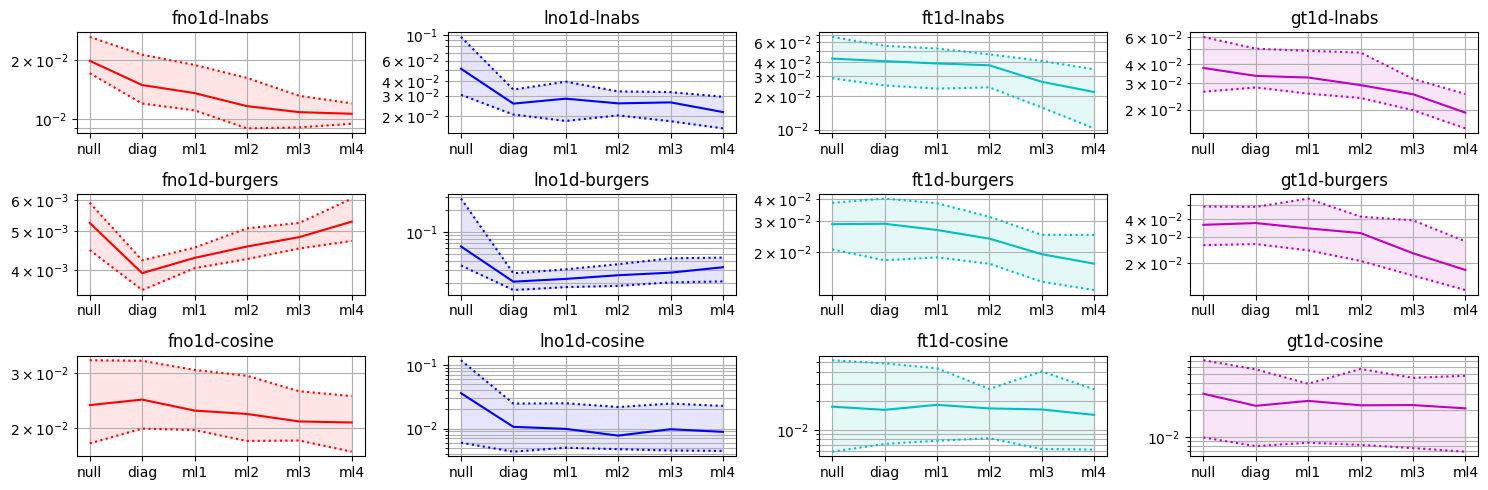

In [14]:
fig = vis_all_model_dataset_residual_trend_on_fix_resolution(log1d_df, resolution=4096)

### All type model with all coarsen and diag-ml4 on 4096

In [15]:
sub_df = log1d_df[(log1d_df.resolution == 4096) & (log1d_df.residual == 'diag')]
table_mean = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['coarse_level'], aggfunc=np.mean)
table_min = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['coarse_level'], aggfunc=np.min)
table_max = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['coarse_level'], aggfunc=np.max)

In [17]:
table_mean.round(4)

coarse_level        0       1       2       3       4
dataset model                                        
burgers fno1d  0.0039  0.0039  0.0039  0.0039  0.0040
        ft1d   0.0280  0.0312  0.0314  0.0281  0.0267
        gt1d   0.0356  0.0372  0.0399  0.0369  0.0377
        lno1d  0.0213  0.0213  0.0205  0.0206  0.0217
cosine  fno1d  0.0225  0.0220  0.0243  0.0245  0.0307
        ft1d   0.0145  0.0123  0.0117  0.0153  0.0294
        gt1d   0.0190  0.0155  0.0245  0.0191  0.0339
        lno1d  0.0056  0.0066  0.0079  0.0114  0.0218
lnabs   fno1d  0.0125  0.0126  0.0132  0.0153  0.0207
        ft1d   0.0390  0.0353  0.0448  0.0430  0.0415
        gt1d   0.0302  0.0332  0.0316  0.0324  0.0389
        lno1d  0.0240  0.0248  0.0244  0.0258  0.0288
poisson fno1d  0.0069  0.0069  0.0075  0.0101  0.0154
        ft1d   0.0365  0.0431  0.0331  0.0354  0.0512
        gt1d   0.0222  0.0222  0.0208  0.0232  0.0258
        lno1d  0.0108  0.0113  0.0115  0.0130  0.0181

### trend on same resolution with different coarsen level

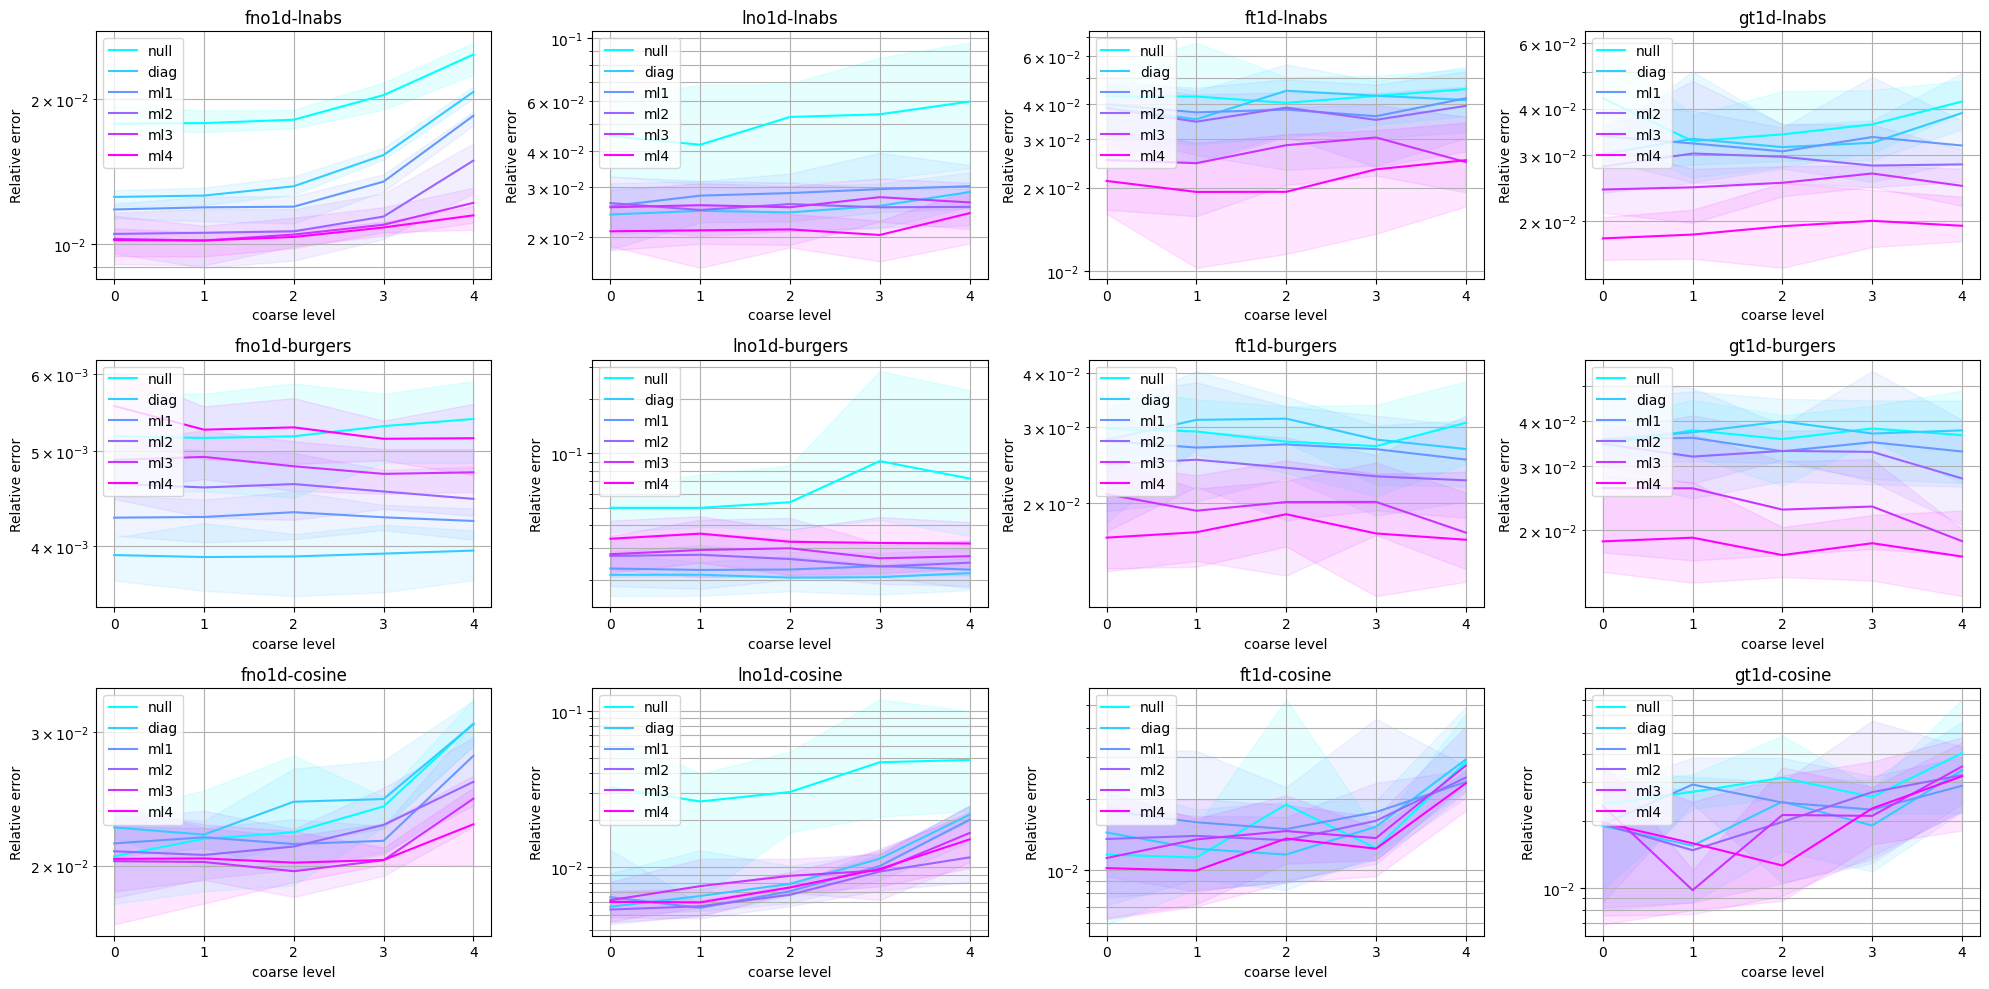

In [18]:
fig, axs = plt.subplots(3, 4, figsize=(20, 10))#, sharey='row')
sub_df = log1d_df[log1d_df.resolution == 4096]
colors = mpl.colormaps['cool']
coarse_levels = [0, 1, 2, 3, 4]
for m, model in enumerate(['fno1d', 'lno1d', 'ft1d', 'gt1d']):
    for d, dataset in enumerate(['lnabs', 'burgers', 'cosine']):
        subsub_df = sub_df[(sub_df.model == model) & (sub_df.dataset == dataset)]            
        table_mean = subsub_df.pivot_table(values='test_l2', index=['coarse_level'], columns=['residual'], aggfunc=np.mean)
        table_min = subsub_df.pivot_table(values='test_l2', index=['coarse_level'], columns=['residual'], aggfunc=np.min)
        table_max = subsub_df.pivot_table(values='test_l2', index=['coarse_level'], columns=['residual'], aggfunc=np.max)
        
        for r, residual in enumerate(['null', 'diag', 'ml1', 'ml2', 'ml3', 'ml4']):
            # axs[d][m].plot(table_mean.index, table_min[[residual]].values.reshape(-1), ":",color=colors(r*0.2))
            # axs[d][m].plot(table_mean.index, table_max[[residual]].values.reshape(-1), ":",color=colors(r*0.2))
            axs[d][m].plot(table_mean.index, table_mean[[residual]].values.reshape(-1), "-",color=colors(r*0.2), label=residual)
            axs[d][m].fill_between(table_mean.index, 
                                   table_min[[residual]].values.reshape(-1),
                                   table_max[[residual]].values.reshape(-1), color=colors(r*0.2), alpha=0.1)
            
        axs[d][m].set_xticks(coarse_levels)
        axs[d][m].set_xticklabels(coarse_levels)
        axs[d][m].set_title("{:}-{:}".format(model, dataset))
        axs[d][m].set_yscale('log')
        axs[d][m].grid(axis='both', which='both')
        axs[d][m].legend(loc='upper left')
        axs[d][m].set_xlabel('coarse level')
        axs[d][m].set_ylabel('Relative error')
        
fig.tight_layout()

### trend on different residual type on different coarsen level

In [14]:
# model1d_df = log1d_agg_df[(log1d_agg_df.model == 'ft1d')]
# model1d_table = pd.pivot_table(model1d_df, values='test_l2', index=['resolution', 'residual'], columns=['dataset', 'coarse_level'])
# model1d_table = model1d_table.reindex(
#     pd.MultiIndex.from_product(
#         [model1d_table.index.levels[0], ['null','diag','ml1', 'ml2', 'ml3', 'ml4']]), axis=0)

In [15]:
# for model_nm in ['ft1d', 'gt1d', 'fno1d', 'lno1d']:
#     model1d_df = log1d_agg_df[(log1d_agg_df.model == model_nm)]
#     model1d_table = pd.pivot_table(model1d_df, values='test_l2', index=['resolution', 'residual'], columns=['dataset', 'coarse_level'])
#     model1d_table = model1d_table.reindex(
#         pd.MultiIndex.from_product(
#             [model1d_table.index.levels[0], ['null','diag','ml1', 'ml2', 'ml3', 'ml4']]), axis=0)

#     fig = plt.figure(figsize=(40, 10))
#     fig.suptitle(model_nm)
#     fig.subplots_adjust(top=0.95)
    
#     bmin = model1d_table['burgers'].min().min()
#     bmax = model1d_table['burgers'].max().max()
#     plt.subplot(1,4,1)
#     plt.title('burgers')
#     sns.heatmap(model1d_table['burgers'], annot=True,  fmt=".2e", cmap='coolwarm', vmin=bmin, vmax=bmax)

#     pmin = model1d_table['poisson'].min().min()
#     pmax = model1d_table['poisson'].max().max()
#     plt.subplot(1,4,2)
#     plt.title('poisson')
#     sns.heatmap(model1d_table['poisson'], annot=True,  fmt=".2e", cmap='coolwarm', vmin=pmin, vmax=pmax)

#     cmin = model1d_table['cosine'].min().min()
#     cmax = model1d_table['cosine'].max().max()
#     plt.subplot(1,4,3)
#     plt.title('cosine')
#     sns.heatmap(model1d_table['cosine'], annot=True,  fmt=".2e", cmap='coolwarm', vmin=cmin, vmax=cmax)

#     lmin = model1d_table['lnabs'].min().min()
#     lmax = model1d_table['lnabs'].max().max()
#     plt.subplot(1,4,4)
#     plt.title('lnabs')
#     sns.heatmap(model1d_table['lnabs'], annot=True,  fmt=".2e", cmap='coolwarm', vmin=lmin, vmax=lmax)

In [20]:
# 2D cases analysis

In [21]:
log2d_paths = glob.glob('../logs/exp2d/*/*/*.csv')
log2d_df = load_accuracy_log(log2d_paths)

100%|██████████| 5472/5472 [00:42<00:00, 127.31it/s]


In [10]:
keep_best = []
not_enough = []
for model in ['fno2d', 'lno2d', 'ft2d', 'gt2d']:
    for dataset in ['darcy', 'invdist']:
        for coarse_level in [0, 1, 2, 3]:
            for residual in ['null', 'diag', 'ml1', 'ml2', 'ml3', 'ml4']:
                for resolution in [85, 141, 211, 421]:
                    sub_df = log2d_df[(log2d_df.model == model) & (log2d_df.dataset == dataset) & (log2d_df.coarse_level == coarse_level) & (log2d_df.residual == residual) & (log2d_df.resolution == resolution)]
                    best_df = sub_df.sort_values(by='test_l2').iloc[:5]
                    if (best_df.shape[0] < 5) & (coarse_level == 0):
                        if pass_check
                        not_enough.append([model, dataset, coarse_level, residual, resolution, best_df.seed.tolist()])
                    
                    keep_best.append(best_df)

log2d_filt_df = pd.concat(keep_best)

In [27]:
pd.DataFrame(not_enough, columns=['model_nm', 'dataset', 'coarse_level', 'residual', 'resolution', 'seeds']).sort_values('residual')

,model_nm,dataset,coarse_level,residual,resolution,seeds
20,lno2d,darcy,0,diag,211,"[0, 1, 3, 2]"
93,gt2d,invdist,0,diag,421,[]
92,gt2d,invdist,0,diag,211,[]
47,ft2d,darcy,0,diag,421,[]
80,gt2d,darcy,0,diag,211,"[1, 4, 3]"
...,...,...,...,...,...,...
79,gt2d,darcy,0,null,421,[]
78,gt2d,darcy,0,null,211,"[4, 1, 3]"
60,ft2d,invdist,0,null,141,[]
90,gt2d,invdist,0,null,211,[]


In [8]:
len(not_enough)

90

### trend on different residual type without coarsen

In [62]:
log2d_df[(log2d_df.resolution == 141) & (log2d_df.coarse_level == 3) & (log2d_df.model == 'fno2d')]

,model,dataset,coarse_level,resolution,residual,seed,test_l2,mcode


In [20]:
sub_df = log2d_df[(log2d_df.resolution == 211) & (log2d_df.coarse_level == 0)]
table_141_c0 = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['residual'])
column_order = ['null', 'diag', 'ml1', 'ml2', 'ml3', 'ml4']
table_141_c0.reindex(column_order, axis=1).round(4)

residual         null    diag     ml1     ml2     ml3     ml4
dataset model                                                
darcy   fno2d  0.0334  0.0131  0.0113  0.0108  0.0111  0.0120
        gt2d   0.0362  0.0940  0.0255     NaN     NaN     NaN
        lno2d  0.0679  0.0293  0.0250     NaN     NaN     NaN
invdist fno2d  0.0322  0.0024  0.0024  0.0025  0.0025  0.0029
        lno2d  0.0272  0.0094     NaN     NaN     NaN     NaN

In [ ]:
# for model_nm in ['fno2d', 'lno2d', 'ft2d', 'gt2d']:
#     res2d_df = log2d_agg_df[(log2d_agg_df.model == model_nm) & (log2d_agg_df.coarse_level == 0)]# & (log_df.dataset != 'burgers')]
#     g = sns.catplot(data=res2d_df, x='residual', y='test_l2', row='dataset', col='resolution', kind='point', order=['null','diag','ml1', 'ml2', 'ml3', 'ml4'], hue='dataset')
#     g.set(yscale='log')
#     g.fig.subplots_adjust(top=0.92)
#     g.fig.suptitle(model_nm)

### trend on same resolution with different coarsen level

In [ ]:
# for model_nm in ['ft2d', 'gt2d', 'fno2d', 'lno2d']:
#     sub_df = log2d_agg_df[(log2d_agg_df.model == model_nm) & (log2d_agg_df.resolution == 85)]
#     g = sns.catplot(data=sub_df, x='coarse_level', y='test_l2', col='residual', row='dataset', kind='point', col_order=['null','diag','ml1', 'ml2', 'ml3', 'ml4'], hue='dataset')
#     g.set(yscale='log')
#     g.fig.subplots_adjust(top=0.92)
#     g.fig.suptitle(model_nm)

In [ ]:
# for model_nm in ['ft2d', 'gt2d', 'fno2d', 'lno2d']:
#     model2d_df = log2d_agg_df[(log2d_agg_df.model == model_nm)]
#     model2d_table = pd.pivot_table(model2d_df, values='test_l2', index=['resolution', 'residual'], columns=['dataset', 'coarse_level'])
#     model2d_table = model2d_table.reindex(
#         pd.MultiIndex.from_product(
#             [model2d_table.index.levels[0], ['null','diag','ml1', 'ml2', 'ml3', 'ml4']]), axis=0)

#     fig = plt.figure(figsize=(20, 10))
#     fig.suptitle(model_nm)
#     fig.subplots_adjust(top=0.95)

#     plt.subplot(1,2,1)
#     plt.title('darcy')
#     sns.heatmap(model2d_table['darcy'], annot=True,  fmt=".2e", cmap='coolwarm', vmin=0, vmax=0.1)
#     plt.subplot(1,2,2)
#     plt.title('invdist')
#     sns.heatmap(model2d_table['invdist'], annot=True,  fmt=".2e", cmap='coolwarm', vmin=0, vmax=0.1)